# 02 — Análise exploratória e alavancas de receita

Cinco perguntas do case: sazonalidade, categorias, delivery e recompra, CLV regional e concentração de sellers. GMV significa a soma do preço dos itens; pedidos `canceled`/`unavailable` ficam fora apenas das métricas comerciais. A checagem de cobertura confirma agosto/2018 completo; setembro e outubro contêm apenas registros residuais.

In [1]:
from pathlib import Path
import os, sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb

# Funciona tanto ao executar a partir da raiz quanto de notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / 'src').is_dir(), 'Não foi possível localizar src/. Abra o notebook dentro do repositório.'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from ifood_analytics.analysis import bootstrap_clustered_mean_difference
DATA = Path(os.getenv('OLIST_GOLD', str(PROJECT_ROOT / 'data' / 'gold'))).expanduser()
assert DATA.exists(), 'Execute o pipeline ou defina OLIST_GOLD para a pasta gold.'
sns.set_theme(style='whitegrid')
orders = pd.read_parquet(DATA / 'fact_orders.parquet')
items = pd.read_parquet(DATA / 'fact_order_items.parquet')
con = duckdb.connect()
con.register('fact_orders', orders)
con.register('fact_order_items', items)


## Escopo analítico sem exclusão física
As facts preservam todos os pedidos e itens, inclusive status cancelados ou indisponíveis. Os marts comerciais aplicam filtros somente às métricas de GMV elegível (soma de `price`); isso não equivale a receita contábil realizada. A tabela abaixo torna explícito o volume fora do recorte; nenhum registro é apagado da bronze, silver ou facts.

In [2]:
status_scope = orders.groupby('order_status').agg(orders=('order_id','nunique'), item_value=('item_revenue','sum'), missing_delivery_date=('order_delivered_customer_date', lambda s: s.isna().sum())).sort_values('orders', ascending=False)
status_scope['included_in_commercial_marts'] = ~status_scope.index.isin(['canceled','unavailable'])
display(status_scope.style.format({'item_value':'R$ {:,.2f}'}))
pd.Series({'fact_order_rows': len(orders), 'commercial_mart_orders': int(status_scope.loc[status_scope.included_in_commercial_marts,'orders'].sum()), 'orders_outside_commercial_scope': int(status_scope.loc[~status_scope.included_in_commercial_marts,'orders'].sum()), 'rows_physically_deleted': 0})

,orders,item_value,missing_delivery_date,included_in_commercial_marts
order_status,,,,
delivered,96478,"R$ 13,221,498.11",8,True
shipped,1107,"R$ 150,727.44",1107,True
canceled,625,"R$ 95,235.27",619,False
unavailable,609,"R$ 2,007.69",609,False
invoiced,314,"R$ 61,526.37",314,True
processing,301,"R$ 60,439.22",301,True
created,5,R$ 0.00,5,True
approved,2,R$ 209.60,2,True


fact_order_rows                    99441
commercial_mart_orders             98207
orders_outside_commercial_scope     1234
rows_physically_deleted                0
dtype: int64

## 1. Qual é a sazonalidade?
A série cresce ao longo da expansão da plataforma; novembro/2017 é o pico, compatível com Black Friday. A comparação por mês do calendário usa apenas 2017 e meses completos de 2018 para reduzir a mistura entre tendência e sazonalidade. Não interpretar crescimento histórico como forecast.

,order_month,orders,revenue,avg_order_value
13,2017-11-01,7423,1003862.14,135.236716
18,2018-04-01,6919,993592.98,143.603553
19,2018-05-01,6833,992871.75,145.305393
17,2018-03-01,7168,981051.06,136.865382
15,2018-01-01,7187,945456.29,131.550896


,avg_revenue,years_observed
calendar_month,,
1,532777.280,2
2,541427.390,2
3,674696.190,2
4,673717.980,2
5,748015.470,2
6,646591.070,2
7,685165.785,2
8,708552.945,2
9,621415.910,1


,orders,first_purchase,last_purchase
order_month,,,
2016-09-01,4,2016-09-04 21:15:19,2016-09-15 12:16:38
2016-10-01,324,2016-10-02 22:07:52,2016-10-22 08:25:27
2016-12-01,1,2016-12-23 23:16:47,2016-12-23 23:16:47
2018-09-01,16,2018-09-03 09:06:57,2018-09-29 09:13:03
2018-10-01,4,2018-10-01 15:30:09,2018-10-17 17:30:18


year,2017,2018,growth_2018_vs_2017
month,,,
1,"R$ 120,098","R$ 945,456",687.2%
2,"R$ 244,959","R$ 837,895",242.1%
3,"R$ 368,341","R$ 981,051",166.3%
4,"R$ 353,843","R$ 993,593",180.8%
5,"R$ 503,159","R$ 992,872",97.3%
6,"R$ 429,917","R$ 863,266",100.8%
7,"R$ 492,287","R$ 878,044",78.4%
8,"R$ 568,246","R$ 848,860",49.4%


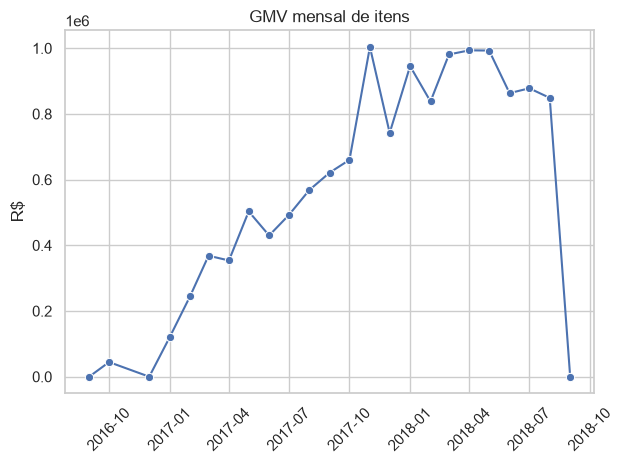

In [3]:
monthly = con.sql("""
    SELECT date_trunc('month', order_purchase_timestamp) AS order_month,
           COUNT(DISTINCT order_id) AS orders, SUM(item_revenue) AS revenue,
           SUM(item_revenue) / COUNT(DISTINCT order_id) AS avg_order_value
    FROM fact_orders
    WHERE order_status NOT IN ('canceled', 'unavailable')
    GROUP BY 1 ORDER BY 1
""").df()
ax = sns.lineplot(data=monthly, x='order_month', y='revenue', marker='o')
ax.set(title='GMV mensal de itens', xlabel='', ylabel='R$'); plt.xticks(rotation=45); plt.tight_layout()
display(monthly.nlargest(5, 'revenue')[['order_month', 'orders', 'revenue', 'avg_order_value']])
# Agosto termina no dia 31; setembro/outubro são residuais e ficam de fora.
complete = monthly[(monthly.order_month >= '2017-01-01') & (monthly.order_month < '2018-09-01')].copy()
complete['calendar_month'] = complete.order_month.dt.month
display(complete.groupby('calendar_month').agg(avg_revenue=('revenue','mean'), years_observed=('order_month','size')))
month_coverage = orders.assign(order_month=lambda d: d.order_purchase_timestamp.dt.to_period('M').dt.to_timestamp()).groupby('order_month').agg(orders=('order_id','nunique'), first_purchase=('order_purchase_timestamp','min'), last_purchase=('order_purchase_timestamp','max'))
display(month_coverage.loc[(month_coverage.index < '2017-01-01') | (month_coverage.index >= '2018-09-01')])
complete['year'] = complete.order_month.dt.year; complete['month'] = complete.order_month.dt.month
yoy = complete.pivot(index='month', columns='year', values='revenue').dropna(subset=[2017, 2018])
yoy['growth_2018_vs_2017'] = yoy[2018] / yoy[2017] - 1
yoy.style.format({2017:'R$ {:,.0f}', 2018:'R$ {:,.0f}', 'growth_2018_vs_2017':'{:.1%}'})

## 2. Quais categorias são mais rentáveis?
A base não contém custos: usamos GMV (soma de `price`) como proxy, declaradamente. A participação das cinco líderes no recorte executivo de março–agosto é calculada ao final do notebook.

,category,orders,revenue,avg_review_score,late_rate
0,health_beauty,8800,1255695.13,4.150318,0.090544
1,watches_gifts,5604,1198185.21,4.027703,0.082807
2,bed_bath_table,9399,1035964.06,3.901177,0.083995
3,sports_leisure,7673,979740.92,4.122436,0.074140
4,computers_accessories,6654,904322.02,3.947467,0.077718
5,furniture_decor,6425,727465.05,3.919355,0.084314
6,housewares,5847,626825.80,4.072770,0.064901
7,cool_stuff,3616,620770.49,4.157551,0.067509
8,auto,3872,586585.73,4.078587,0.082870
9,garden_tools,3505,481009.94,4.056215,0.079663


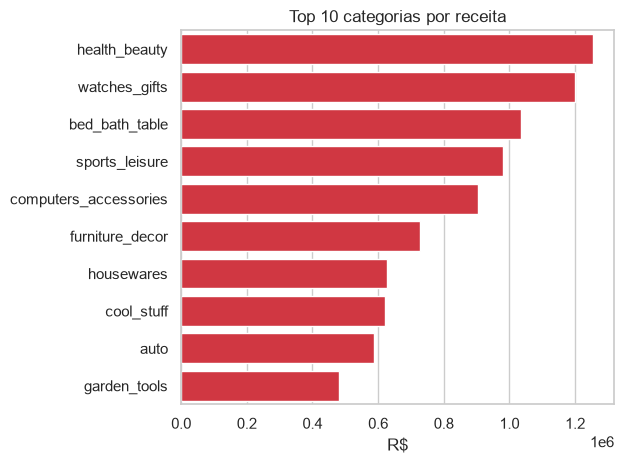

In [4]:
category = con.sql("""
    SELECT category, COUNT(DISTINCT order_id) AS orders, SUM(price) AS revenue,
           AVG(review_score) AS avg_review_score, AVG(CAST(is_late AS INTEGER)) AS late_rate
    FROM fact_order_items
    WHERE order_status NOT IN ('canceled', 'unavailable')
    GROUP BY 1 ORDER BY revenue DESC LIMIT 10
""").df()
sns.barplot(data=category, y='category', x='revenue', color='#EA1D2C').set(title='Top 10 categorias por receita', xlabel='R$', ylabel=''); plt.tight_layout()
category[['category', 'orders', 'revenue', 'avg_review_score', 'late_rate']]

### Profundidade: concentração, frete e qualidade por categoria
Receita sozinha pode privilegiar categorias com experiência ruim ou frete pesado. A matriz abaixo adiciona participação, ticket por pedido, peso do frete e qualidade operacional.

,category,orders,revenue,freight,review,late_rate,revenue_share,ticket_per_order,freight_burden
42,health_beauty,8800,"R$ 1,255,695",181970.650000,4.15,9.1%,9.3%,R$ 142.69,14.5%
64,watches_gifts,5604,"R$ 1,198,185",100107.260000,4.03,8.3%,8.9%,R$ 213.81,8.4%
50,bed_bath_table,9399,"R$ 1,035,964",204422.070000,3.90,8.4%,7.7%,R$ 110.22,19.7%
51,sports_leisure,7673,"R$ 979,741",167503.710000,4.12,7.4%,7.3%,R$ 127.69,17.1%
56,computers_accessories,6654,"R$ 904,322",146619.560000,3.95,7.8%,6.7%,R$ 135.91,16.2%
41,furniture_decor,6425,"R$ 727,465",172160.990000,3.92,8.4%,5.4%,R$ 113.22,23.7%
15,housewares,5847,"R$ 626,826",145209.340000,4.07,6.5%,4.6%,R$ 107.20,23.2%
66,cool_stuff,3616,"R$ 620,770",83315.750000,4.16,6.8%,4.6%,R$ 171.67,13.4%
1,auto,3872,"R$ 586,586",92020.910000,4.08,8.3%,4.3%,R$ 151.49,15.7%
63,garden_tools,3505,"R$ 481,010",98515.260000,4.06,8.0%,3.6%,R$ 137.24,20.5%


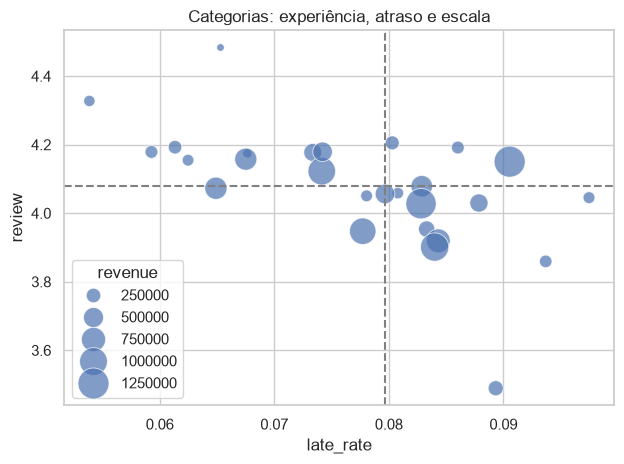

In [5]:
category_full = con.sql("""
    SELECT category, COUNT(DISTINCT order_id) AS orders, SUM(price) AS revenue,
           SUM(freight_value) AS freight, AVG(review_score) AS review,
           AVG(CAST(is_late AS INTEGER)) AS late_rate
    FROM fact_order_items WHERE order_status NOT IN ('canceled','unavailable') GROUP BY 1
""").df()
category_full['revenue_share'] = category_full.revenue / category_full.revenue.sum()
category_full['ticket_per_order'] = category_full.revenue / category_full.orders
category_full['freight_burden'] = category_full.freight / category_full.revenue
display(category_full.nlargest(10,'revenue').style.format({'revenue':'R$ {:,.0f}','revenue_share':'{:.1%}','ticket_per_order':'R$ {:.2f}','freight_burden':'{:.1%}','review':'{:.2f}','late_rate':'{:.1%}'}))
focus = category_full[category_full.orders >= 500]
sns.scatterplot(data=focus, x='late_rate', y='review', size='revenue', sizes=(30,500), alpha=.7)
plt.axvline(focus.late_rate.median(), color='gray', ls='--'); plt.axhline(focus.review.median(), color='gray', ls='--'); plt.title('Categorias: experiência, atraso e escala'); plt.tight_layout()

**Leitura:** entre as categorias de maior receita, `bed_bath_table` combina review abaixo de 4,0 com frete equivalente a 19,7% da receita; `furniture_decor` chega a 23,7%. Isso sugere separar cross-sell de ações de eficiência logística: escalar demanda sem tratar frete/experiência pode deteriorar valor.

## 3. Delivery afeta recompra?
Comparamos pedidos entregues no prazo/atrasados e marcamos se houve pedido posterior do mesmo `customer_unique_id`. É associação observacional, sujeita a censura temporal e confundidores.

In [6]:
purchase_history = orders[~orders.order_status.isin(['canceled','unavailable'])].sort_values(['customer_unique_id', 'order_purchase_timestamp']).copy()
purchase_history['next_purchase_at'] = purchase_history.groupby('customer_unique_id').order_purchase_timestamp.shift(-1)
delivered = purchase_history[purchase_history.order_status.eq('delivered')].copy()
delivered['has_next_order'] = delivered.next_purchase_at.notna()
# Linhas sem SLA/cliente não participam desta métrica, mas permanecem nas facts.
delivery_sample = delivered.dropna(subset=['is_late', 'customer_unique_id']).copy()
delivery = delivery_sample.groupby('is_late').agg(orders=('order_id','size'), repeat_rate=('has_next_order','mean'), review=('review_score','mean'), delivery_days=('delivery_days','mean'))
display(delivery.style.format({'repeat_rate':'{:.2%}', 'review':'{:.2f}', 'delivery_days':'{:.1f}'}))
# Reamostra clientes inteiros: pedidos de um mesmo cliente não são independentes.
difference, ci_low, ci_high = bootstrap_clustered_mean_difference(
    delivery_sample, cluster_column='customer_unique_id', group_column='is_late',
    value_column='has_next_order', group_a=True, group_b=False,
)
pd.Series({'diferença_atrasado_menos_prazo': difference, 'IC95%_inferior': ci_low, 'IC95%_superior': ci_high, 'unidade_bootstrap':'customer_unique_id'}).to_frame('taxa')

,orders,repeat_rate,review,delivery_days
is_late,,,,
False,88644,3.31%,4.29,10.8
True,7826,2.72%,2.57,31.5


,taxa
diferença_atrasado_menos_prazo,-0.005893
IC95%_inferior,-0.009721
IC95%_superior,-0.002024
unidade_bootstrap,customer_unique_id


A tabela apresenta associação entre atraso, recompra e review. O IC95% é calculado por bootstrap agrupado em `customer_unique_id`, preservando todos os pedidos de cada cliente sorteado. Mesmo que o intervalo de recompra fique abaixo de zero, o desenho observacional não elimina censura temporal ou confundidores; o resultado justifica experimento de SLA/recuperação, não promessa causal.

### Robustez: mesma janela de oportunidade de recompra
Pedidos perto do fim da base tiveram menos tempo para recomprar. A análise de sensibilidade restringe a coorte a compras com pelo menos 90 dias de observação e mede recompra nos 90 dias seguintes.

In [7]:
valid_orders = purchase_history.copy()
valid_orders['repurchase_90d'] = (valid_orders.next_purchase_at - valid_orders.order_purchase_timestamp).dt.days.between(0,90)
cutoff = valid_orders.order_purchase_timestamp.max() - pd.Timedelta(days=90)
eligible = valid_orders[(valid_orders.order_status.eq('delivered')) & (valid_orders.order_purchase_timestamp <= cutoff) & valid_orders.is_late.notna() & valid_orders.customer_unique_id.notna()].copy()
sensitivity = eligible.groupby('is_late').agg(orders=('order_id','size'), repurchase_90d=('repurchase_90d','mean'), review=('review_score','mean'))
display(sensitivity.style.format({'repurchase_90d':'{:.2%}','review':'{:.2f}'}))
diff90, low90, high90 = bootstrap_clustered_mean_difference(
    eligible, cluster_column='customer_unique_id', group_column='is_late',
    value_column='repurchase_90d', group_a=True, group_b=False,
)
pd.Series({'difference_90d':diff90,'IC95%_lower':low90,'IC95%_upper':high90,'eligible_until':cutoff, 'unidade_bootstrap':'customer_unique_id'}).to_frame('value')

,orders,repurchase_90d,review
is_late,,,
False,71810,2.53%,4.28
True,6810,2.25%,2.45


,value
difference_90d,-0.002864
IC95%_lower,-0.006647
IC95%_upper,0.001007
eligible_until,2018-06-05 09:06:57
unidade_bootstrap,customer_unique_id


**Resultado da sensibilidade:** a tabela usa a mesma inferência agrupada por cliente e uma janela uniforme de 90 dias. Se o IC95% cruzar zero, a evidência de efeito sobre recompra é frágil à censura; a queda de review permanece o sinal mais robusto para priorizar um experimento logístico.

## 4. Como varia o CLV por região?
CLV é GMV histórico observado por cliente, porque a janela curta não sustenta um modelo de lifetime futuro.

In [8]:
clv = pd.read_parquet(DATA / 'mart_customer_value.parquet')
region = clv.groupby('customer_state').agg(customers=('customer_unique_id','nunique'), revenue=('observed_clv','sum'), avg_clv=('observed_clv','mean'), repeat_rate=('is_repeat_customer','mean')).sort_values('revenue', ascending=False)
region.head(10).style.format({'revenue':'R$ {:,.0f}', 'avg_clv':'R$ {:,.2f}', 'repeat_rate':'{:.2%}'})

,customers,revenue,avg_clv,repeat_rate
customer_state,,,,
SP,39743,"R$ 5,165,053",R$ 129.96,3.15%
RJ,12238,"R$ 1,811,476",R$ 148.02,3.37%
MG,11129,"R$ 1,573,519",R$ 141.39,2.97%
RS,5233,"R$ 742,640",R$ 141.91,3.13%
PR,4824,"R$ 676,978",R$ 140.34,2.96%
SC,3497,"R$ 517,971",R$ 148.12,2.66%
BA,3243,"R$ 507,062",R$ 156.36,2.81%
DF,2056,"R$ 300,285",R$ 146.05,2.97%
GO,1933,"R$ 288,755",R$ 149.38,3.16%


### Robustez: maturidade comparável de clientes
CLV observado favorece clientes que entraram cedo na janela. A visão abaixo limita a comparação a clientes cuja primeira compra ocorreu ao menos 180 dias antes do fim da base; ela não transforma o indicador em CLV preditivo, mas reduz o viés de exposição temporal.

In [9]:
analysis_end = orders.order_purchase_timestamp.max()
mature_cutoff = analysis_end - pd.Timedelta(days=180)
mature_clv = clv[clv.first_order_at <= mature_cutoff]
mature_region = mature_clv.groupby('customer_state').agg(customers=('customer_unique_id','nunique'), observed_clv=('observed_clv','mean'), repeat_rate=('is_repeat_customer','mean')).query('customers >= 500').sort_values('observed_clv', ascending=False)
display(pd.Series({'analysis_end':analysis_end,'mature_cutoff':mature_cutoff,'mature_customers':len(mature_clv),'all_customers':len(clv)}))
mature_region.style.format({'observed_clv':'R$ {:.2f}','repeat_rate':'{:.2%}'})

analysis_end        2018-10-17 17:30:18
mature_cutoff       2018-04-20 17:30:18
mature_customers                  68017
all_customers                     94990
dtype: object

,customers,observed_clv,repeat_rate
customer_state,,,
PA,733,R$ 185.76,3.14%
MT,642,R$ 180.02,4.21%
CE,988,R$ 173.01,1.92%
PE,1152,R$ 167.40,2.69%
MA,554,R$ 165.31,3.07%
BA,2337,R$ 154.82,3.29%
RJ,9097,R$ 149.10,4.08%
DF,1418,R$ 145.50,3.74%
GO,1439,R$ 143.20,3.61%


SP lidera por escala; RJ/MG completam o maior pool acionável. CLV médio isolado não basta para priorizar UFs pequenas. A tabela de maturidade deve ser usada como checagem de robustez antes de priorizar uma UF apenas pelo valor observado.

### Profundidade: escala versus valor regional
Estados pequenos podem ter CLV médio alto por ruído amostral. A comparação inclui índice contra a média nacional e restringe a visualização a estados com pelo menos 500 clientes.

,customer_state,customers,revenue,avg_clv,repeat_rate,clv_index,revenue_share
0,SP,39743,"R$ 5,165,053",R$ 129.96,3.15%,0.91x,38.3%
1,RJ,12238,"R$ 1,811,476",R$ 148.02,3.37%,1.04x,13.4%
2,MG,11129,"R$ 1,573,519",R$ 141.39,2.97%,1.00x,11.7%
3,RS,5233,"R$ 742,640",R$ 141.91,3.13%,1.00x,5.5%
4,PR,4824,"R$ 676,978",R$ 140.34,2.96%,0.99x,5.0%
5,SC,3497,"R$ 517,971",R$ 148.12,2.66%,1.04x,3.8%
6,BA,3243,"R$ 507,062",R$ 156.36,2.81%,1.10x,3.8%
7,DF,2056,"R$ 300,285",R$ 146.05,2.97%,1.03x,2.2%
8,GO,1933,"R$ 288,755",R$ 149.38,3.16%,1.05x,2.1%
9,ES,1950,"R$ 273,622",R$ 140.32,2.97%,0.99x,2.0%


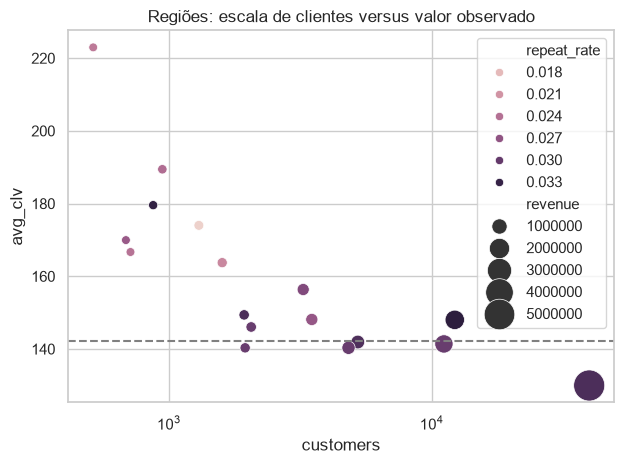

In [10]:
national_clv = clv.observed_clv.mean()
region['clv_index'] = region.avg_clv / national_clv
region['revenue_share'] = region.revenue / region.revenue.sum()
reliable_region = region[region.customers >= 500].reset_index()
display(reliable_region.style.format({'revenue':'R$ {:,.0f}','avg_clv':'R$ {:.2f}','repeat_rate':'{:.2%}','clv_index':'{:.2f}x','revenue_share':'{:.1%}'}))
sns.scatterplot(data=reliable_region, x='customers', y='avg_clv', size='revenue', hue='repeat_rate', sizes=(40,500))
plt.axhline(national_clv, color='gray', ls='--'); plt.xscale('log'); plt.title('Regiões: escala de clientes versus valor observado'); plt.tight_layout()

**Leitura:** SP concentra escala, mas seu CLV médio fica em 0,91× a média nacional. RJ está em 1,04× e BA em 1,10×, embora com bases menores. A decisão de investimento deve combinar tamanho do pool, custo de aquisição e margem; CLV médio isolado favoreceria indevidamente estados pequenos.

## 5. Há concentração de sellers?
Curva acumulada, HHI e Gini distinguem concentração operacional, desigualdade da cauda e dominância individual.

In [11]:
sellers = pd.read_parquet(DATA / 'mart_seller_performance.parquet').sort_values('revenue', ascending=False).reset_index(drop=True)
sellers['cumulative_share'] = sellers.revenue.cumsum() / sellers.revenue.sum()
shares = sellers.revenue / sellers.revenue.sum()
summary = {'top_1_pct': sellers.head(int(np.ceil(len(sellers)*.01))).revenue.sum()/sellers.revenue.sum(), 'top_10_pct': sellers.head(int(np.ceil(len(sellers)*.10))).revenue.sum()/sellers.revenue.sum(), 'HHI': (shares**2).sum()}
pd.Series(summary).to_frame('value')

,value
top_1_pct,0.261790
top_10_pct,0.675001
HHI,0.003595


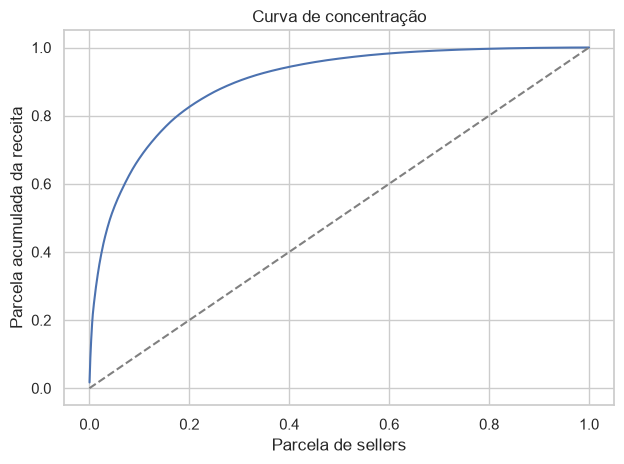

In [12]:
sns.lineplot(x=(sellers.index + 1) / len(sellers), y=sellers.cumulative_share)
plt.plot([0,1],[0,1], '--', color='gray'); plt.xlabel('Parcela de sellers'); plt.ylabel('Parcela acumulada da receita'); plt.title('Curva de concentração'); plt.tight_layout()

### Profundidade: Gini e risco operacional dos sellers
HHI mede dominância; Gini mede desigualdade da distribuição. A matriz receita × atraso identifica sellers relevantes para gestão de SLA, sem confundir concentração com monopólio.

,value
gini_revenue,0.790655
HHI,0.003595
revenue_weighted_late_rate,0.078960
sellers_with_30plus_orders,634.000000


,seller_id,orders,revenue,avg_review_score,late_rate
0,4869f7a5dfa277a7dca6462dcf3b52b2,1131,229237.63,4.125545,0.115854
1,53243585a1d6dc2643021fd1853d8905,358,222776.05,4.075980,0.040000
2,4a3ca9315b744ce9f8e9374361493884,1804,200326.12,3.804082,0.109800
3,fa1c13f2614d7b5c4749cbc52fecda94,584,192842.13,4.344234,0.101900
4,7c67e1448b00f6e969d365cea6b010ab,982,187923.89,3.341445,0.095941
5,7e93a43ef30c4f03f38b393420bc753a,332,172583.88,4.238806,0.055901
6,da8622b14eb17ae2831f4ac5b9dab84a,1314,160236.57,4.063754,0.072997
7,7a67c85e85bb2ce8582c35f2203ad736,1159,141715.54,4.235573,0.058874
8,1025f0e2d44d7041d6cf58b6550e0bfa,915,138968.55,3.853107,0.092254
9,955fee9216a65b617aa5c0531780ce60,1286,135159.70,4.052490,0.080842


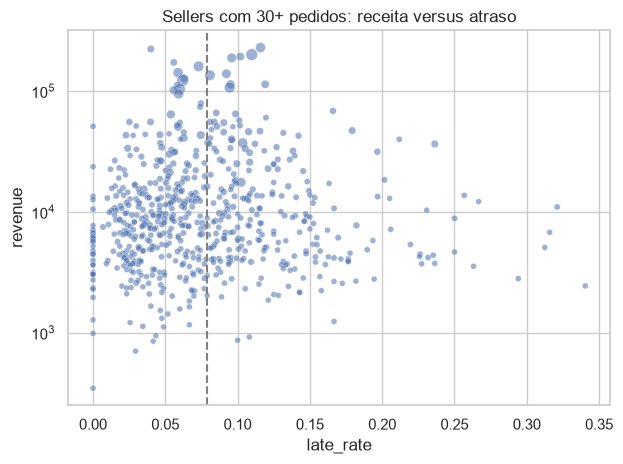

In [13]:
ascending_revenue = np.sort(sellers.revenue.to_numpy())
n = len(ascending_revenue); gini = (2*np.sum(np.arange(1,n+1)*ascending_revenue)/(n*ascending_revenue.sum())) - (n+1)/n
seller_risk = sellers[(sellers.orders >= 30) & sellers.late_rate.notna()].copy()
weighted_late_rate = np.average(seller_risk.late_rate, weights=seller_risk.revenue)
display(pd.Series({'gini_revenue':gini,'HHI':(shares**2).sum(),'revenue_weighted_late_rate':weighted_late_rate,'sellers_with_30plus_orders':len(seller_risk)}).to_frame('value'))
sns.scatterplot(data=seller_risk, x='late_rate', y='revenue', size='orders', alpha=.55, legend=False)
plt.axvline(weighted_late_rate, color='gray', ls='--'); plt.yscale('log'); plt.title('Sellers com 30+ pedidos: receita versus atraso'); plt.tight_layout()
seller_risk.nlargest(10,'revenue')[['seller_id','orders','revenue','avg_review_score','late_rate']]

## Ponte para a recomendação executiva
Os cenários do one-pager são recalculados abaixo para março–agosto de 2018: os últimos seis meses de calendário com cobertura completa. Agosto termina no dia 31; setembro e outubro têm poucos registros residuais e não entram no recorte. As hipóteses lineares separam GMV incremental potencial de GMV apenas sob exposição operacional.

In [14]:
# Janela executiva: os seis últimos meses inteiros observados na cobertura mensal.
recent_start, recent_end = pd.Timestamp('2018-03-01'), pd.Timestamp('2018-09-01')
commercial = ~orders.order_status.isin(['canceled','unavailable'])
recent_orders = orders[commercial & orders.order_purchase_timestamp.between(recent_start, recent_end, inclusive='left')]
recent_items = items[(~items.order_status.isin(['canceled','unavailable'])) & items.order_purchase_timestamp.between(recent_start, recent_end, inclusive='left')]
top5_categories = recent_items.groupby('category').price.sum().nlargest(5)
top3_state_revenue = recent_orders[recent_orders.customer_state.isin(['SP','RJ','MG'])].item_revenue.sum()
late_exposure = recent_orders.loc[recent_orders.is_late.eq(True), 'item_revenue'].sum()
scenario = pd.DataFrame([
    {'alavanca':'Top 5 categorias','base':'R$ {:.2f}'.format(top5_categories.sum()),'premissa':'+3% de GMV','cenario':'R$ {:.2f}'.format(top5_categories.sum()*.03),'tipo':'incremental potencial'},
    {'alavanca':'SP/RJ/MG','base':'R$ {:.2f}'.format(top3_state_revenue),'premissa':'+1% de GMV','cenario':'R$ {:.2f}'.format(top3_state_revenue*.01),'tipo':'incremental potencial'},
    {'alavanca':'Pedidos atrasados','base':'R$ {:.2f}'.format(late_exposure),'premissa':'−25% de atrasos','cenario':'R$ {:.2f}'.format(late_exposure*.25),'tipo':'exposição tratada, não uplift'},
])
display(pd.Series({'periodo':f'{recent_start:%Y-%m} a {(recent_end-pd.Timedelta(days=1)):%Y-%m}','revenue_total':recent_orders.item_revenue.sum(),'top5_share':top5_categories.sum()/recent_orders.item_revenue.sum(),'late_rate':recent_orders.is_late.mean()}))
scenario

periodo          2018-03 a 2018-08
revenue_total           5557685.69
top5_share                0.408448
late_rate                 0.087656
dtype: object

,alavanca,base,premissa,cenario,tipo
0,Top 5 categorias,R$ 2270025.62,+3% de GMV,R$ 68100.77,incremental potencial
1,SP/RJ/MG,R$ 3570102.21,+1% de GMV,R$ 35701.02,incremental potencial
2,Pedidos atrasados,R$ 490458.15,−25% de atrasos,R$ 122614.54,"exposição tratada, não uplift"


## Síntese
Top 10% dos sellers geram 67,5% da receita e o Gini de 0,79 confirma forte desigualdade na cauda; ao mesmo tempo, HHI de 0,0036 e top seller com 1,7% indicam ausência de monopolista. Entre sellers com 30+ pedidos, o atraso ponderado por receita é 7,9%, permitindo priorizar SLAs por impacto. As alavancas recomendadas continuam sendo disponibilidade/cross-sell nas categorias líderes, aquisição mensurável em SP/RJ/MG e confiabilidade logística — mas a análise de 90 dias enfraquece a hipótese de recompra, reforçando a necessidade de experimento causal.